# **Hipótesis A: Sin IA**
**Autores**: Luna Yue Hernández Guerra y Jorge Lorenzo Lorenzo

**Fecha**: Diciembre 2025

**Asignatura**: Procesamiento de Imágenes, Audio y Vídeo

---

## **Preprocesamiento**
A continuación, se exponen los diferentes pasos del preprocesado de las imágenes llevados a cabo. Estos pasos son secuenciales, es decir, cada uno se aplica a los resultados del paso anterior. Los pasos son los siguientes:
1. Buscar y segmentar la ROI
2. Ecualizar y normalizar el histograma
3. Aplicar un filtro bilateral
4. Aplicar un realce de crestas
5. Refinar la ROI

Importación de librerías:

In [54]:
import os
import cv2 as cv
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import norm

### **Buscar y segmentar la ROI**
El objetivo del primer paso del preprocesado es obtener el núcleo de la huella. Según el estudio de Simón-Zorita, este paso es realmente importante para conseguir un buen preprocesado de huellas.

Para ello, creamos dos funciones: `mejor_roi()` y `recortar_roi()`.
- `mejor_roi()`: Esta función obtiene la región de interés de una imagen. Dicha región de interés se define como la región de tamaño `ventana`x`ventana` donde más píxeles negros hay. Para ello, se recorre la imagen con un kernel de tamaño `ventana`x`ventana` dando pasos de `paso` píxeles y se obtiene la suma de píxeles negros. Una vez recorrida toda la imagen, se devuelven las coordenadas donde inicia la ventana y el ancho y alto de la misma, con lo que se pueden calcular las coordenadas de la región con mayor número de píxeles negros.
- `recortar_roi()`: Esta función guarda las regiones de interés de todas las imágenes de la base de datos que se encuentra en la ruta `db_path` en disco, en un directorio `out_path` especificado. Para ello, hace uso de la función `mejor_roi()` tras convertir las imágenes a escala de grises y binarizarlas usando `cv.THRESH_BINARY + cv.THRESH_OTSU`. La binarización combinada es sugerencia de ChatGPT para que el umbral se establezca dinámicamente.

In [55]:
def mejor_roi(image, ventana=500, paso=20):
    H, W = image.shape
    w = min(ventana, W, H)
    h = min(ventana, W, H)
    mejor_ventana = (0, 0, w, h)
    mejor_suma = -1

    for y in range(0, H - h + 1, paso):
        for x in range(0, W - w + 1, paso):
            region = image[y:y+h, x:x+w]
            suma = np.sum(region == 0)

            if suma > mejor_suma:
                mejor_suma = suma
                mejor_ventana = (x, y, w, h)

    return mejor_ventana

def recortar_roi(db_path, out_path, ventana=500, paso=15):
    users = os.listdir(db_path)

    for user in users:
        user_folder = os.path.join(db_path, user)

        if not os.path.isdir(user_folder):
            continue

        image_files = [f for f in os.listdir(user_folder) if f.lower().endswith(".png")]
        if len(image_files) < 2:
            continue
        
        out_dir = os.path.join(out_path, user, "roi")
        os.makedirs(out_dir, exist_ok=True)

        for filename in image_files:
            img_path = os.path.join(user_folder, filename)
            img = cv.imread(img_path)

            if img is None:
                continue

            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            _, image = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU) # Otsu: sugerencia de GPT
            x, y, w, h = mejor_roi(image, ventana=ventana, paso=paso)
            roi = img[y:y+h, x:x+w]
            cv.imwrite(os.path.join(out_dir, filename), roi)

### **Ecualizar y normalizar el histograma**
El siguiente paso a realizar es ecualizar y normalizar el histograma. Con esto, queremos mejorar el contraste de la imagen. Esta técnica la aprendimos en prácticas anteriores donde ecualizar el histograma de una imagen nos permitía encontrar un equilibrio entre brillos y sombras. Para ello,  usamos la función `ecualizar_histograma()`.
- `ecualizar_histograma()`: Esta función, para cada imagen de la base de datos que se encuentra en `db_path`, convierte la imagen a escala de grises, ecualiza el histograma con `cv.equalizeHist()` y la guarda en disco en el directorio `out_path` especificado.

In [56]:
def ecualizar_histograma(db_path, out_path):
    users = os.listdir(db_path)

    for user in users:
        user_folder = os.path.join(out_path, user, "roi")

        if not os.path.isdir(user_folder):
            continue

        image_files = [f for f in os.listdir(user_folder) if f.lower().endswith('.png')]
        if len(image_files) < 2:
            continue

        out_dir = os.path.join(out_path, user, "equalized")
        os.makedirs(out_dir, exist_ok=True)

        for filename in image_files:
            img_path = os.path.join(user_folder, filename)
            image = cv.imread(img_path)
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            equalized = cv.equalizeHist(gray)
            cv.imwrite(os.path.join(out_dir, filename), equalized)

### **Aplicar un filtro bilateral**
A continuación, procedemos con la aplicación del filtro bilateral, cuyo objetivo es eliminar ruido pero no las texturas. Este procedimiento lo aprendimos en prácticas anteriores donde vimos la efectividad de los distintos tipos de filtros. De dicha práctica, sacamos la conclusión de que si no queremos difuminar demasiado la imagen, debíamos utilizar valores bajos de *sigma*. Para aplicarlo, definimos la función `aplicar_filtro_bilateral()`.
- `aplicar_filtro_bilateral()`: Esta función convierte cada imagen de la base de datos ubicada en `db_path` en escala de grises y le aplica el filtro bilateral con la función `cv.bilateralFilter`. Los resultados los guarda en disco en el directorio `out_path` especificado.

In [57]:
def aplicar_filtro_bilateral(db_path, out_path):
    users = os.listdir(db_path)
    for user in users:
        user_folder = os.path.join(out_path, user, "equalized")
        if not os.path.isdir(user_folder):
            print(f"No existe directorio: {user_folder}")
            continue

        image_files = [f for f in os.listdir(user_folder) if f.lower().endswith('.png')]
        if len(image_files) < 2:
            continue

        out_dir = os.path.join(out_path, user, "bilateral_filter")
        os.makedirs(out_dir, exist_ok=True)

        for filename in image_files:
            img_path = os.path.join(user_folder, filename)
            image = cv.imread(img_path)
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            bilateral = cv.bilateralFilter(gray, d=10, sigmaColor=10, sigmaSpace=10)
            cv.imwrite(os.path.join(out_dir, filename), bilateral)

### **Aplicar un realce de crestas**
El siguiente paso, es realizar el realce de crestas con operadores de bordes Sobel con el fin de poder discriminar mejor entre crestas y valles. Este paso es una implementación de la teoría explicada en la primera parte de la asignatura. Para ello, creamos la función `realzar_crestas()`.
- `realzar_crestas()`:  Esta función convierte a escala de grises cada imagen de la base de datos ubicada en `db_path` y le aplica los operadores de Sobel, tanto verticales como horizontales. La ponderación de cada gradiente la obtuvimos de la [documentación de OpenCV](#https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html). Por último, se normaliza la imagen resultante y se pasa a `CV_8U` para solventar el *warning* `[ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.`. Esto fue la solución al *warning* que nos dio ChatGPT. Los resultados los guarda en disco en el directorio `out_path` especificado.

In [58]:
def realzar_crestas(db_path, out_path):
    users = os.listdir(db_path)
    for user in users:
        user_folder = os.path.join(out_path, user, "bilateral_filter")
        if not os.path.isdir(user_folder):
            continue

        image_files = [f for f in os.listdir(user_folder) if f.lower().endswith('.png')]
        if len(image_files) < 2:
            continue

        out_dir = os.path.join(out_path, user, "sobel")
        os.makedirs(out_dir, exist_ok=True)

        for filename in image_files:
            img_path = os.path.join(user_folder, filename)
            image = cv.imread(img_path)
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
            sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
            # https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
            abs_grad_x = cv.convertScaleAbs(sobelx)
            abs_grad_y = cv.convertScaleAbs(sobely)
            grad = cv.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
            sobel_8u = cv.normalize(grad, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8) # Código de GPT para solventar warning: [ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
            cv.imwrite(os.path.join(out_dir, filename), sobel_8u)

### **Refinar la ROI**
El último paso del preprocesado es refinar la región de interés. El objetivo es eliminar los bordes falsos que se hayan podido detectar en el paso anterior. Este procedimiento es una idea del artículo de Simón-Zorita y se lo pedimos al ChatGPT. La función obtenida es `refinar_roi()`.
- `refinar_roi()`: Esta función recorta el 8% de los márgenes de la imagen con el fin de eliminar los bordes que no pertenecen a la huella. Seguidamente, elimina el posible ruido más pequeño que el `kernel` y luego aplica un filtro mediano, que trata de eliminar el ruido sal-pimienta. Finalmente, normaliza la imagen. Este procedimiento lo aplica a todas las imágenes de la base de datos que se encuentra en `db_path` y guarda los resultados en disco en el directorio `out_path` especificado. 

In [59]:
def refinar_roi(db_path, out_path):
    users = os.listdir(db_path)

    for user in users:
        user_folder = os.path.join(out_path, user, "sobel")
        if not os.path.isdir(user_folder):
            continue

        image_files = [f for f in os.listdir(user_folder)
                       if f.lower().endswith(".png")]
        if not image_files:
            continue

        out_dir = os.path.join(out_path, user, "refinadas")
        os.makedirs(out_dir, exist_ok=True)

        for filename in image_files:
            img_path = os.path.join(user_folder, filename)
            image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if image is None:
                continue

            h, w = image.shape
            pct = 0.08
            m = int(min(h, w) * pct)
            crop = image[m:h-m, m:w-m]
            kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
            clean = cv.morphologyEx(crop, cv.MORPH_OPEN, kernel, iterations=1)
            clean = cv.medianBlur(clean, 3)
            refinada = cv.normalize(clean, None, 0, 255, cv.NORM_MINMAX)
            cv.imwrite(os.path.join(out_dir, filename), refinada)

In [60]:
DB_PATH = r"data"
OUT_PATH = "output2"
os.makedirs(OUT_PATH, exist_ok=True)
print(20*"=")
print("PREPROCESADO")
print(20*"=")
print("Paso 1. Buscar y segmentar la ROI")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  
print("Paso 2. Ecualizar y normalizar el histograma")
ecualizar_histograma(DB_PATH, OUT_PATH)
print("Paso 3. Aplicar un filtro bilateral")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)
print("Paso 4. Aplicar un realce de crestas")
realzar_crestas(DB_PATH, OUT_PATH)
print("Paso 5. Refinar la ROI eliminando bordes falsos")
refinar_roi(DB_PATH, OUT_PATH)
print(20*"-")
print("Preprocesado finalizado")
print(20*"-")

PREPROCESADO
Paso 1. Buscar y segmentar la ROI
Paso 2. Ecualizar y normalizar el histograma
Paso 3. Aplicar un filtro bilateral
Paso 4. Aplicar un realce de crestas
Paso 5. Refinar la ROI eliminando bordes falsos
--------------------
Preprocesado finalizado
--------------------


## **Entrenamiento SIFT (búsqueda de mejores parámetros)**

In [61]:
def cargar_dataset(out_path, sift):
    dataset = []
    users = sorted([u for u in os.listdir(out_path) 
                   if os.path.isdir(os.path.join(out_path, u)) and u.lower() != "test"])
    for user in users:
        folder = os.path.join(out_path, user, "refinadas")
        if not os.path.isdir(folder): continue
        for f in sorted([x for x in os.listdir(folder) if x.lower().endswith(".png")]):
            img = cv.imread(os.path.join(folder, f), cv.IMREAD_GRAYSCALE)
            if img is not None:
                kp, des = sift.detectAndCompute(cv.bitwise_not(img), None)
                if des is not None and len(kp) > 0:
                    dataset.append({'id': user, 'filename': f, 'kp': kp, 'des': des})
    return dataset

def match_knn_ratio(des1, des2, ratio=0.75, k=2): # RECICLADO DE LA PRÁCTICA 5 DE LA ASIGNATURA
    """
    Empareja descriptores con KNN, aplica el test de ratio de Lowe
    y devuelve los matches ordenados.
    """
    bf = cv.BFMatcher(cv.NORM_L2, crossCheck=False)
    knn = bf.knnMatch(des1, des2, k=k)
    good = []

    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair[0], pair[1]

        if m.distance < ratio * n.distance:
            good.append(m)

    return sorted(good, key=lambda x: x.distance)

def calcular_similitud(bf, kp_src, des_src, kp_dst, des_dst): # RECICLADO DE LA PRÁCTICA 5 DE LA ASIGNATURA
    if des_src is None or des_dst is None: 
        return 0, 0.0
    matches = match_knn_ratio(des_src, des_dst)
    good_n = len(matches)
    if good_n >= 4:
        src = np.float32([kp_src[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([kp_dst[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        _, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if mask is not None:
            return int(mask.sum()), (int(mask.sum()) / len(matches)) * 100.0
    return 0, 0.0


def evaluar_configuracion_sift(out_path, params):
    sift = cv.SIFT_create(**params)
    bf = cv.BFMatcher()
    dataset = cargar_dataset(out_path, sift)
    gen, imp = [], []
    for i in range(0, len(dataset)):
        for j in range(i + 1, len(dataset)):
            img_A, img_B = dataset[i], dataset[j]
            _, ratio = calcular_similitud(bf, img_A['kp'], img_A['des'], img_B['kp'], img_B['des'])
            if img_A['id'] == img_B['id']: gen.append(ratio)
            else: imp.append(ratio)
    return gen, imp

def gestionar_optimizacion_sift(out_path, params_file):
    mejor_config = {}
    buscar = True
    if os.path.exists(params_file):
        print(f"Archivo de configuración encontrado: {params_file}")
        if input("¿Recalcular hiperparámetros (s/n)? ").lower().strip() != 's':
            buscar = False
            with open(params_file, 'r') as f: mejor_config = json.load(f)
            print(f"Configuración cargada: {mejor_config}")
    if buscar:
        print("Iniciando búsqueda de mejores parámetros...")
        param_grid = {'nfeatures': [1000, 2000], 'contrastThreshold': [0.01, 0.03], 'edgeThreshold': [10, 15], 'sigma': [1.4, 1.6]}
        mejor_eer = 100.0
        import itertools
        keys, values = zip(*param_grid.items())
        total_combs = [dict(zip(keys, v)) for v in itertools.product(*values)]
        for idx, params in enumerate(total_combs):
            print(f"Probando [{idx+1}/{len(total_combs)}]: {params} ...", end="")
            gen, imp = evaluar_configuracion_sift(out_path, params)
            if not gen or not imp: 
                print(" Sin datos.")
                continue
            umbrales = np.linspace(0, 100, 50)
            diffs = [abs((np.sum(np.array(gen) < u)/len(gen)) - (np.sum(np.array(imp) >= u)/len(imp))) for u in umbrales]
            eer_local = min(diffs) * 100
            print(f" EER aprox: {eer_local:.2f}")
            if eer_local < mejor_eer:
                mejor_eer = eer_local
                mejor_config = params
        print(f"Mejor configuración guardada con EER ~{mejor_eer:.2f}")
        with open(params_file, 'w') as f: json.dump(mejor_config, f)
    return mejor_config

In [62]:
PARAMS_FILE = "mejor_config_sift.json"
mejor_config = gestionar_optimizacion_sift(OUT_PATH, PARAMS_FILE)

Archivo de configuración encontrado: mejor_config_sift.json
Iniciando búsqueda de mejores parámetros...
Probando [1/16]: {'nfeatures': 1000, 'contrastThreshold': 0.01, 'edgeThreshold': 10, 'sigma': 1.4} ... EER aprox: 38.39
Probando [2/16]: {'nfeatures': 1000, 'contrastThreshold': 0.01, 'edgeThreshold': 10, 'sigma': 1.6} ... EER aprox: 42.86
Probando [3/16]: {'nfeatures': 1000, 'contrastThreshold': 0.01, 'edgeThreshold': 15, 'sigma': 1.4} ... EER aprox: 25.00
Probando [4/16]: {'nfeatures': 1000, 'contrastThreshold': 0.01, 'edgeThreshold': 15, 'sigma': 1.6} ... EER aprox: 38.39
Probando [5/16]: {'nfeatures': 1000, 'contrastThreshold': 0.03, 'edgeThreshold': 10, 'sigma': 1.4} ... EER aprox: 38.39
Probando [6/16]: {'nfeatures': 1000, 'contrastThreshold': 0.03, 'edgeThreshold': 10, 'sigma': 1.6} ... EER aprox: 42.86
Probando [7/16]: {'nfeatures': 1000, 'contrastThreshold': 0.03, 'edgeThreshold': 15, 'sigma': 1.4} ... EER aprox: 25.00
Probando [8/16]: {'nfeatures': 1000, 'contrastThreshold'

## **Entrenamiento con mejores hiperparámetros**

In [63]:
print("Calculando métricas de entrenamiento...")
genuinos_train, impostores_train = evaluar_configuracion_sift(OUT_PATH, mejor_config)

Calculando métricas de entrenamiento...


In [64]:

def calcular_umbral_optimo(genuinos, impostores):
    umbrales = np.linspace(0, 100, 500)
    gen_arr, imp_arr = np.array(genuinos), np.array(impostores)
    diffs = []
    for u in umbrales:
        frr = np.sum(gen_arr < u) / len(gen_arr) if len(gen_arr) else 0
        far = np.sum(imp_arr >= u) / len(imp_arr) if len(imp_arr) else 0
        diffs.append(abs(frr*100 - far*100))
    return umbrales[np.argmin(diffs)]

In [65]:
mejor_umbral = calcular_umbral_optimo(genuinos_train, impostores_train)
print(f"Umbral óptimo calculado: {mejor_umbral:.2f}%")

Umbral óptimo calculado: 38.48%


In [66]:
def dibujar_gaussiana(genuinos, impostores, mejor_umbral):
    plt.figure(figsize=(8, 6))
    x = np.linspace(0, 100, 500)
    plt.gca().set_facecolor('#f0f0f0')
    if len(impostores) > 1:
        mu, std = norm.fit(impostores)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:blue', lw=3, label='Impostores')
        plt.fill_between(x, y, 0, where=(x >= mejor_umbral), facecolor='tab:blue', alpha=0.4, hatch='///', label='FAR')
    if len(genuinos) > 1:
        mu, std = norm.fit(genuinos)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:orange', lw=3, label='Genuinos')
        plt.fill_between(x, y, 0, where=(x < mejor_umbral), facecolor='tab:orange', alpha=0.4, hatch='///', label='FRR')
    plt.axvline(x=mejor_umbral, color='k', linestyle='--', label=f'Umbral {mejor_umbral:.1f}%')
    plt.title('Función densidad de probabilidad de puntuaciones genuinas e impostoras')
    plt.xlabel('Score (Similitud %)')
    plt.ylabel('Densidad')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


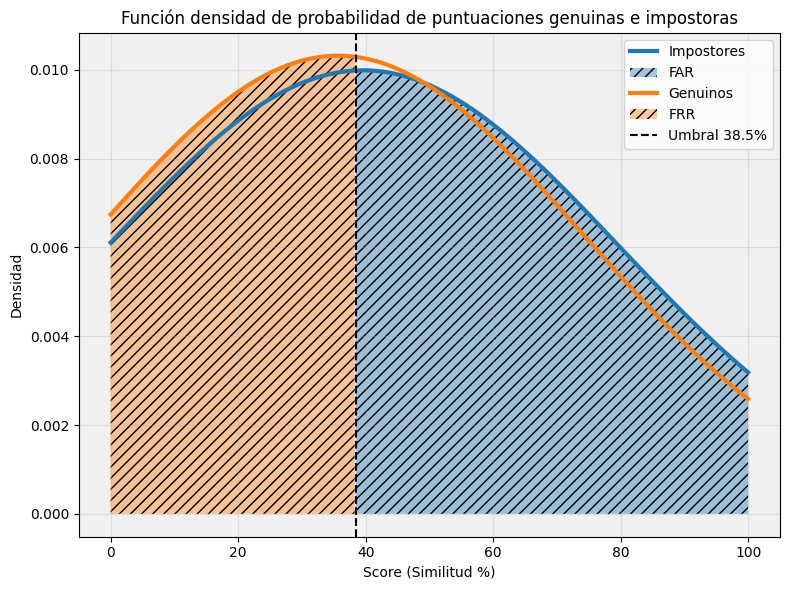

In [67]:

dibujar_gaussiana(genuinos_train, impostores_train, mejor_umbral)

## **Validación**

In [68]:

def test_autenticacion_usuario(test_path, out_path_db, params, umbral):
    """
    Menú interactivo y ejecución del test.
    AHORA RETORNA LAS LISTAS DE SCORES DEL TEST (GENUINOS E IMPOSTORES).
    """
    users = sorted([d for d in os.listdir(out_path_db) if os.path.isdir(os.path.join(out_path_db, d)) and d.lower() != "test"])
    if not users:
        print("No hay usuarios en la BD.")
        return [], []

    print("\n--- SELECCIÓN DE USUARIO REFERENCIA ---")
    for i, u in enumerate(users): print(f"[{i}] {u}")
    
    sel = input(f"Elige usuario (Enter={users[0]}): ").strip()
    ref_user = users[0]
    
    if sel.isdigit() and int(sel) < len(users): ref_user = users[int(sel)]
    elif sel in users: ref_user = sel
    
    print(f"\nVerificando contra: {ref_user} (Umbral: {umbral:.2f})")
    
    sift = cv.SIFT_create(**params)
    bf = cv.BFMatcher()
    ref_dir = os.path.join(out_path_db, ref_user, "refinadas")
    refs = []
    
    if os.path.exists(ref_dir):
        for f in os.listdir(ref_dir):
            img = cv.imread(os.path.join(ref_dir, f), cv.IMREAD_GRAYSCALE)
            if img is not None:
                kp, des = sift.detectAndCompute(cv.bitwise_not(img), None)
                if des is not None: refs.append((kp, des))
    
    test_dir = os.path.join(test_path, "refinadas")
    print(f"{'ARCHIVO':<30} | {'SCORE':<6} | {'RESULTADO'}")
    print("-" * 50)
    
    # Listas para guardar los resultados DE ESTE TEST
    test_genuinos = []
    test_impostores = []

    if os.path.exists(test_dir):
        for f in os.listdir(test_dir):
            img = cv.imread(os.path.join(test_dir, f), cv.IMREAD_GRAYSCALE)
            if img is None: continue
            kp, des = sift.detectAndCompute(cv.bitwise_not(img), None)
            
            best = 0.0
            for r_kp, r_des in refs:
                _, ratio = calcular_similitud(bf, kp, des, r_kp, r_des)
                if ratio > best: best = ratio
            
            res = "ACEPTADO" if best >= umbral else "RECHAZADO"
            print(f"{f:<30} | {best:<6.2f} | {res}")

            # CLASIFICACIÓN PARA LA DET:
            # Asumimos que si el nombre del archivo contiene el ID del usuario referencia, es genuino.
            # Si no, asumimos que es un impostor.
            if ref_user in f:
                test_genuinos.append(best)
            else:
                test_impostores.append(best)
                
    return test_genuinos, test_impostores

In [69]:
OUT_TEST_PATH = "output/test"

test_gen, test_imp = test_autenticacion_usuario(OUT_TEST_PATH, OUT_PATH, mejor_config, mejor_umbral)


--- SELECCIÓN DE USUARIO REFERENCIA ---
[0] crd_0813f
[1] crd_0814f
[2] crd_0815f
[3] crd_0816f
[4] crd_0817f
[5] crd_0818f
[6] crd_0819f
[7] crd_0820f

Verificando contra: crd_0813f (Umbral: 38.48)
ARCHIVO                        | SCORE  | RESULTADO
--------------------------------------------------
crd_0814s_01.png               | 62.50  | ACEPTADO
crd_0815f_01.png               | 100.00 | ACEPTADO
crd_0817f_01.png               | 100.00 | ACEPTADO
crd_0819f_01.png               | 100.00 | ACEPTADO


In [70]:


def dibujar_det(genuinos, impostores, mejor_umbral):
    """Dibuja la curva DET. Protegida contra falta de datos."""
    plt.figure(figsize=(8, 6))
    
    # PROTECCIÓN: Si no hay datos (porque en el test solo hay 2 fotos iguales), avisar.
    if len(genuinos) == 0 and len(impostores) == 0:
        plt.text(0.5, 0.5, "NO HAY DATOS SUFICIENTES\nPARA GENERAR CURVA DET", 
                 horizontalalignment='center', verticalalignment='center', fontsize=14)
        plt.title('2. Curva DET (Sin datos)')
        plt.show()
        return

    far_l, frr_l = [], []
    g_arr, i_arr = np.array(genuinos), np.array(impostores)
    
    for u in np.linspace(0, 100, 1000):
        # Evitamos división por cero si alguna lista está vacía
        frr = (np.sum(g_arr < u) / len(g_arr) * 100) if len(g_arr) > 0 else 0
        far = (np.sum(i_arr >= u) / len(i_arr) * 100) if len(i_arr) > 0 else 0
        frr_l.append(frr)
        far_l.append(far)

    plt.plot(far_l, frr_l, 'k-', lw=3, label='Rendimiento del Test')
    plt.plot([0, 100], [0, 100], 'k--', alpha=0.2)
    
    # Punto operativo actual
    f_op = (np.sum(i_arr >= mejor_umbral) / len(i_arr) * 100) if len(i_arr) > 0 else 0
    r_op = (np.sum(g_arr < mejor_umbral) / len(g_arr) * 100) if len(g_arr) > 0 else 0
    
    plt.plot(f_op, r_op, 'rx', markersize=14, markeredgewidth=3, label=f'Resultados (Umb={mejor_umbral:.1f})')
    
    plt.title('Curva DET (Resultados del TEST)')
    plt.xlabel('Falsa Aceptación (FAR %)')
    plt.ylabel('Falso Rechazo (FRR %)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

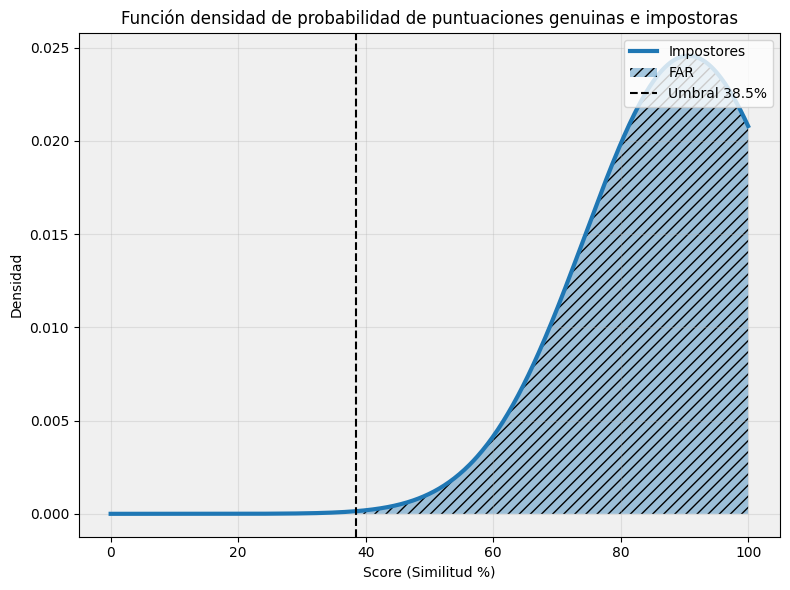

NOTA: La curva DET puede verse incompleta o vacía porque hay muy pocas imágenes en el Test.


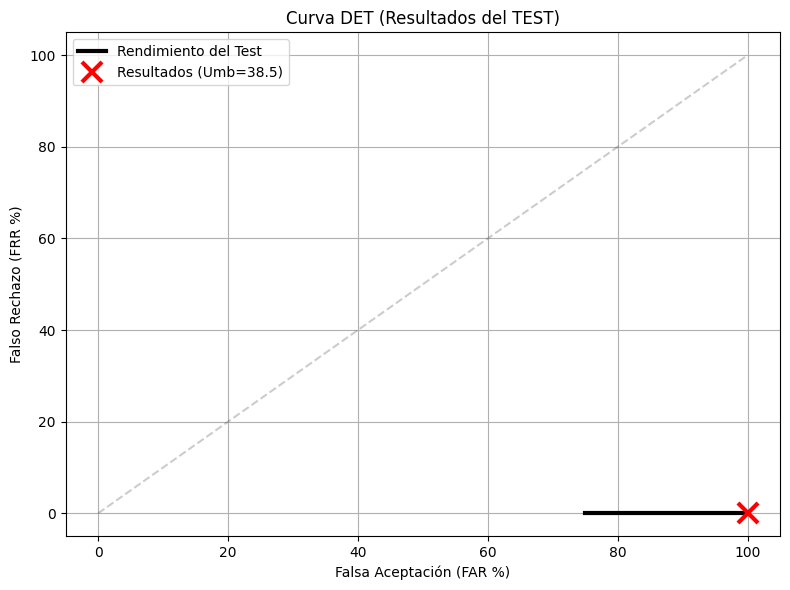

In [71]:
dibujar_gaussiana(test_gen, test_imp, mejor_umbral)

# Aviso si hay pocos datos
if len(test_gen) + len(test_imp) < 5:
    print("NOTA: La curva DET puede verse incompleta o vacía porque hay muy pocas imágenes en el Test.")
    
dibujar_det(test_gen, test_imp, mejor_umbral)